# Análisis de Proyecto Integrador de Aprendizaje Automatizado

Como objetivo de estudio tenemos presente identificar resultados y los que estos significan de aquellos estudiantes con mayor riesgo de abandonar sus estudios académicos y ayudar a encontrar estrategias preventivas que favorezcan su permanencia pues recopila información académica, socioeconómica y de hábitos de estudio para la toma de decisiones orientadas a mejorar la retención de información de estos estudiantes.

Para ello iniciamos con nuestro análisis de la base

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [34]:
dataset = pd.read_csv('data.csv', sep=';')

In [35]:
print("Dimensiones:", dataset.shape)

Dimensiones: (4424, 37)


In [36]:
dataset.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [37]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [38]:
dataset.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [39]:
dataset.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

Encontramos que nuestra base está libre de datos faltantes, así que tenemos el total de información requerida para el estudio.

In [40]:
dataset.Target.value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Distribución de variables numéricas:


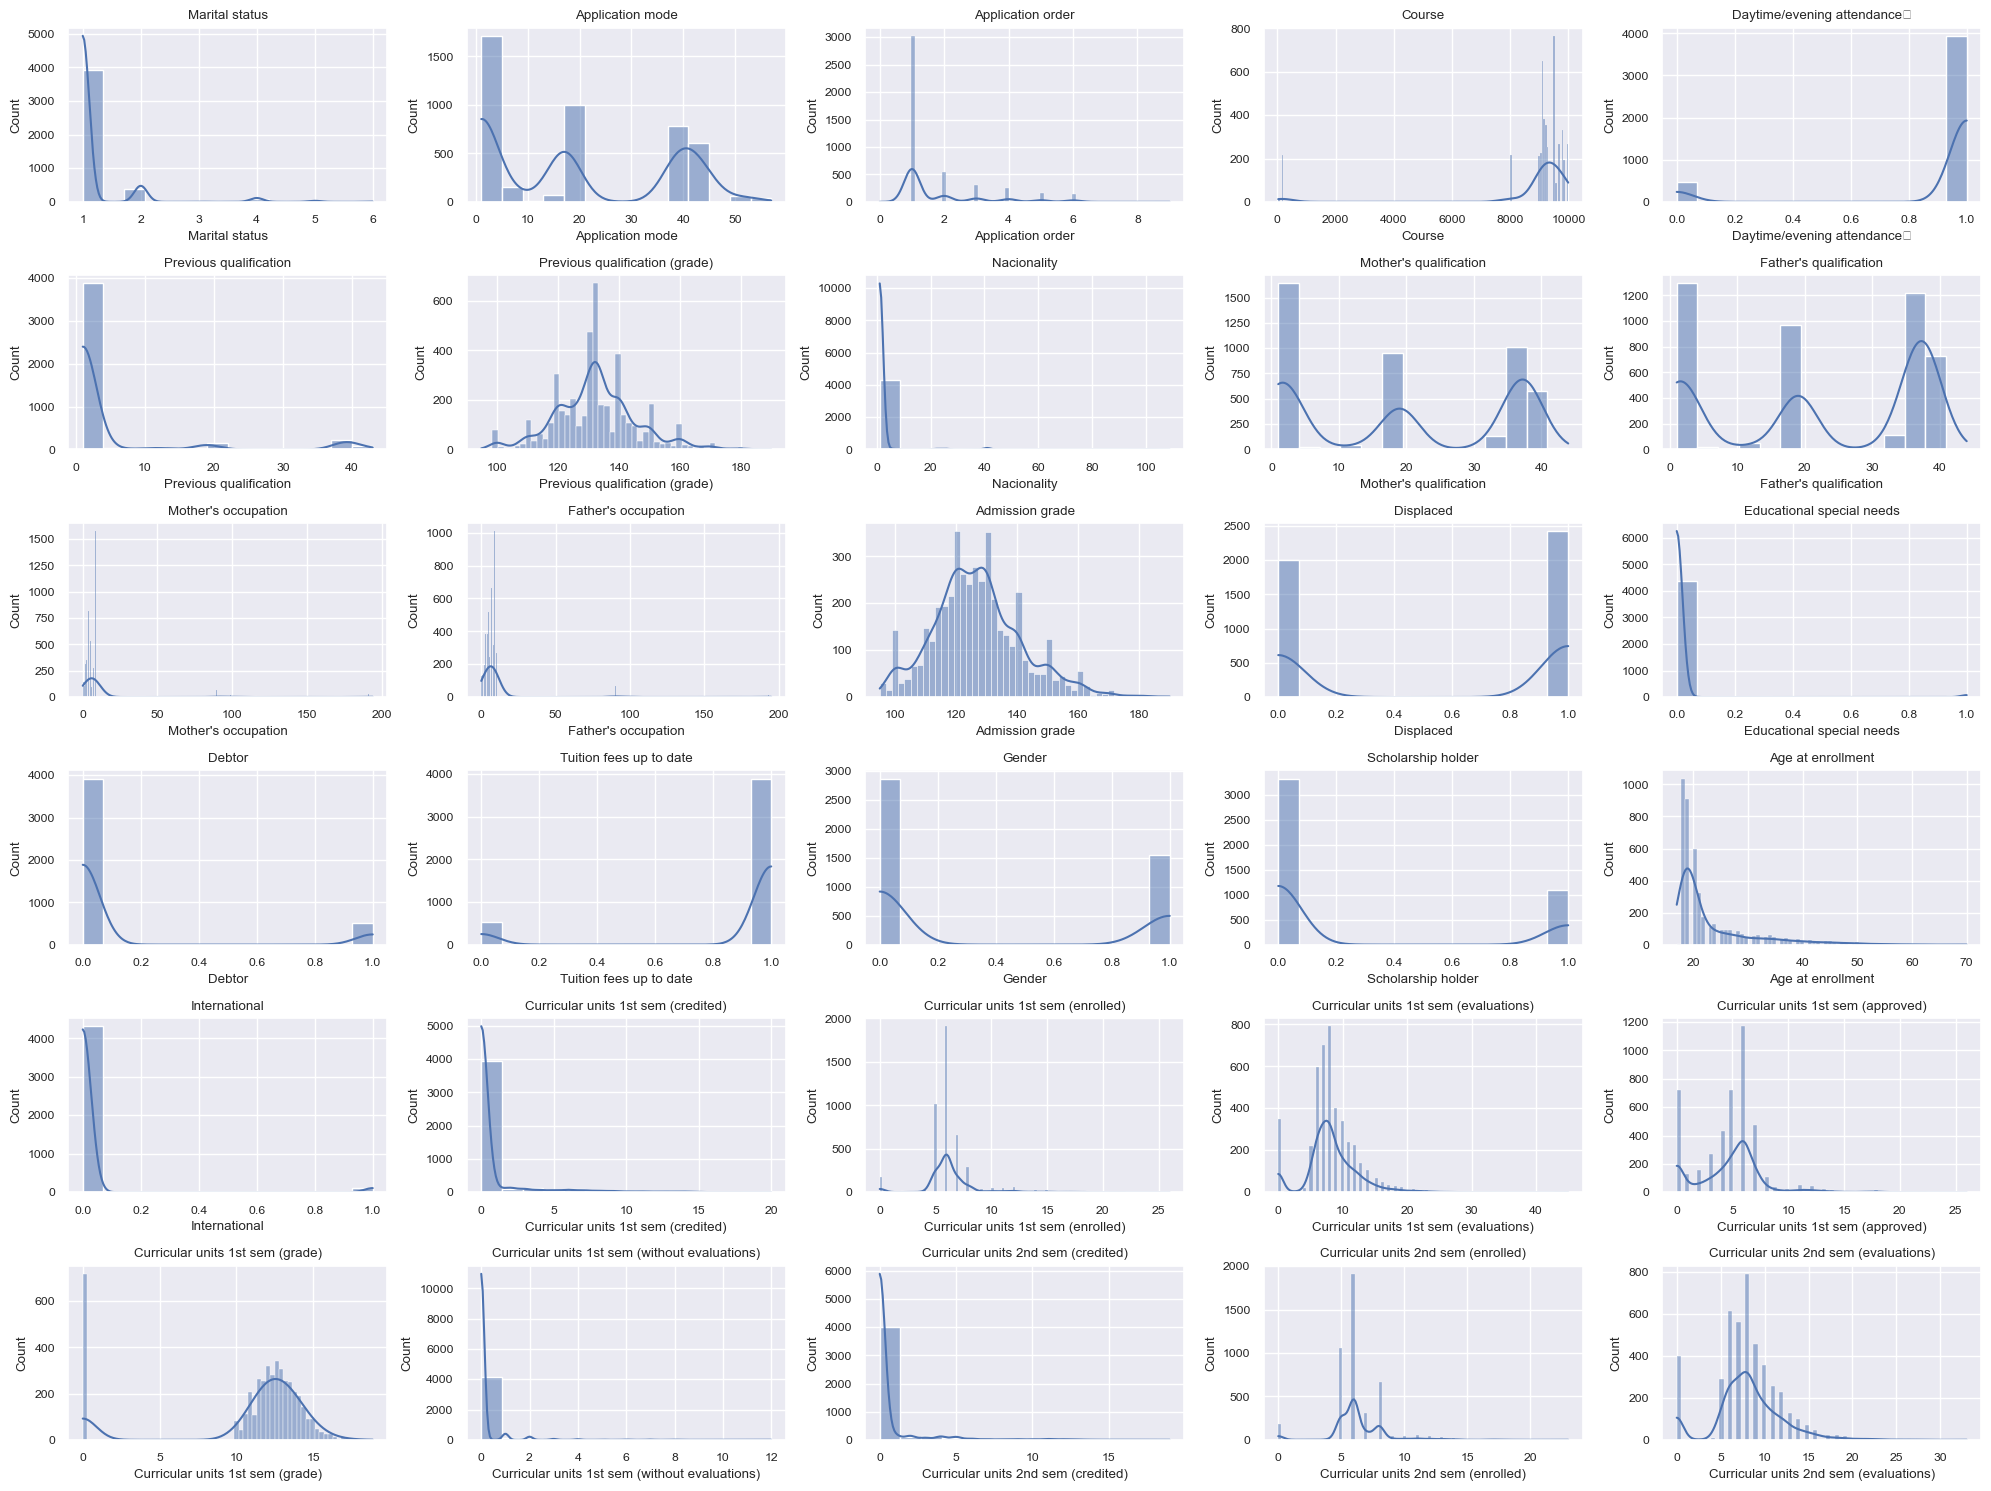

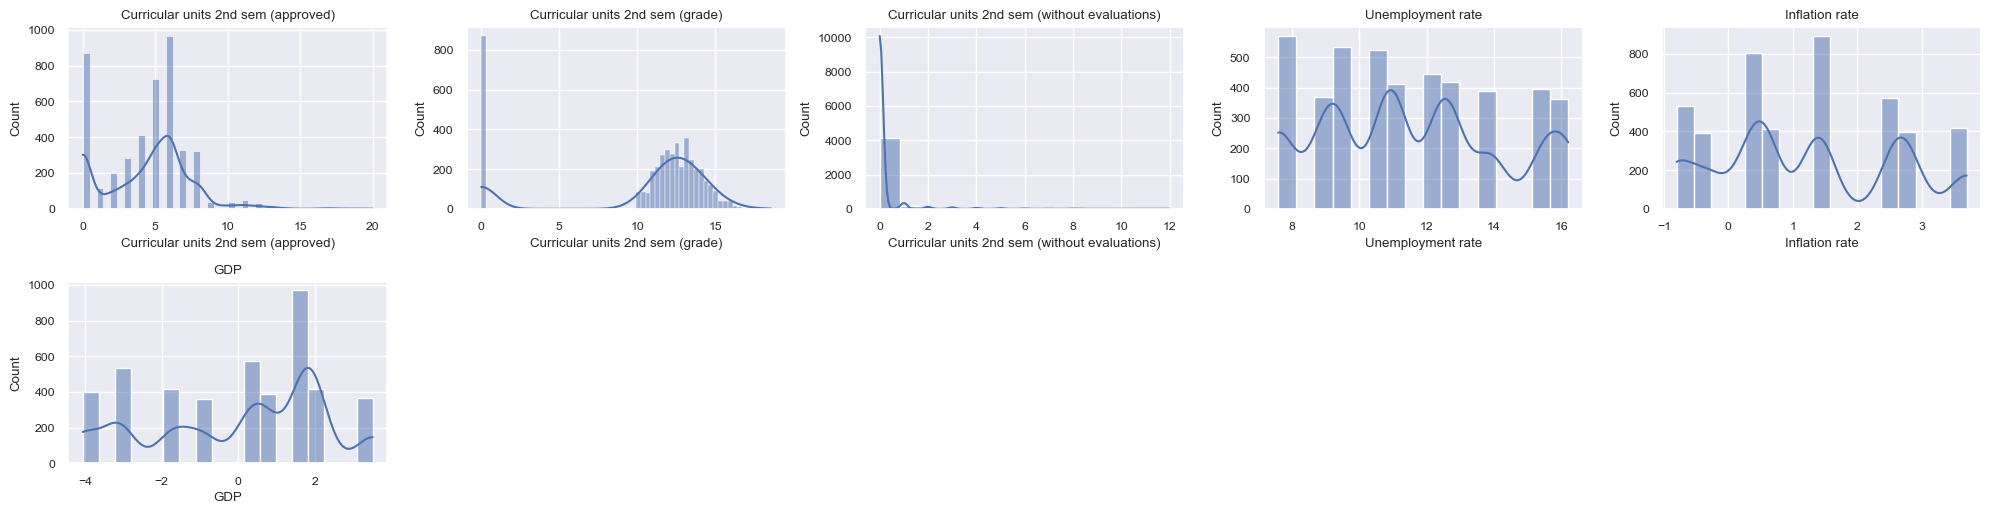

In [41]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist() 
print("\nDistribución de variables numéricas:")
chunk_size = 30
for j in range(0, len(numeric_cols), chunk_size):
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(numeric_cols[j:j+chunk_size]):
        plt.subplot(6, 5, i+1)
        sns.histplot(dataset[col], kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()

En variables como estado civil, nacionalidad y género presentan distribuciones asimétricas, lo que puede decir que  la mayoría de estudiantes escogieron la misma opción, como solteros, misma país o mayoría de género.

En las variables como la calificación de la madre/padre y su ocupación presentan distribuciones multimodales, indicando diferentes niveles educativos, al igual que ocupaciones repetidas. 
En la variable de edad al momento de la inscripción se ve una concentración de edades cercanas a los 18 a 25 años, pero con una cola larga que indica edades mayores de quienes entraron algo "tarde" a la universidad.

En grado de admisión tiene una distribución anormal con un valor medio en 130 siendo una admisión consistente.

En calificaciones previas se ve muestra asimetría positiva con mayoría de valores bajos y pocos casos con calificaciones altas previas.

En unidades curriculares de 1er y 2do semestre se ven varios picos que pueden representar diferentes cargas académicas, y en las notas hay una tendencia a concentrarse en rangos medios-altos.

En la variable que evalua quienes no dieron evaluaciones tiene una alta concentración en cero por lo que la mayoría de los estudiantes completa todas sus evaluaciones y un pequeño grupo no.

En las asistencias diurna/nocturna tiene una distribución bimodal clara pues como hay 0 (no) y 1 (sí) indicando grupos definidos en turnos diurnos y nocturnos.

En variables como deudor, cuotas de matrícula al día, beneficiario de beca, desplazado, necesidades educativas especiales e internacional casi todas muestran distribuciones binarias, con categorías bastante repetidas, como que la mayoría no presentan deudas, no son internacionales o no tienen necesidades especiales.

Y en variables como tasa de desempleo, tasa de inflación y el PIB muestran variabilidad con patrones cíclicos o multimodales, lo que puede dar a decir que la mayoría de los estudiantes tienen una capacidad de permanencia en la universidad por condiciones económicas.

Con estos resultados que presentan algunas excepcione, vemos cuáles serían datos atípicos:

Número de columnas numéricas: 36
Columnas numéricas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment 

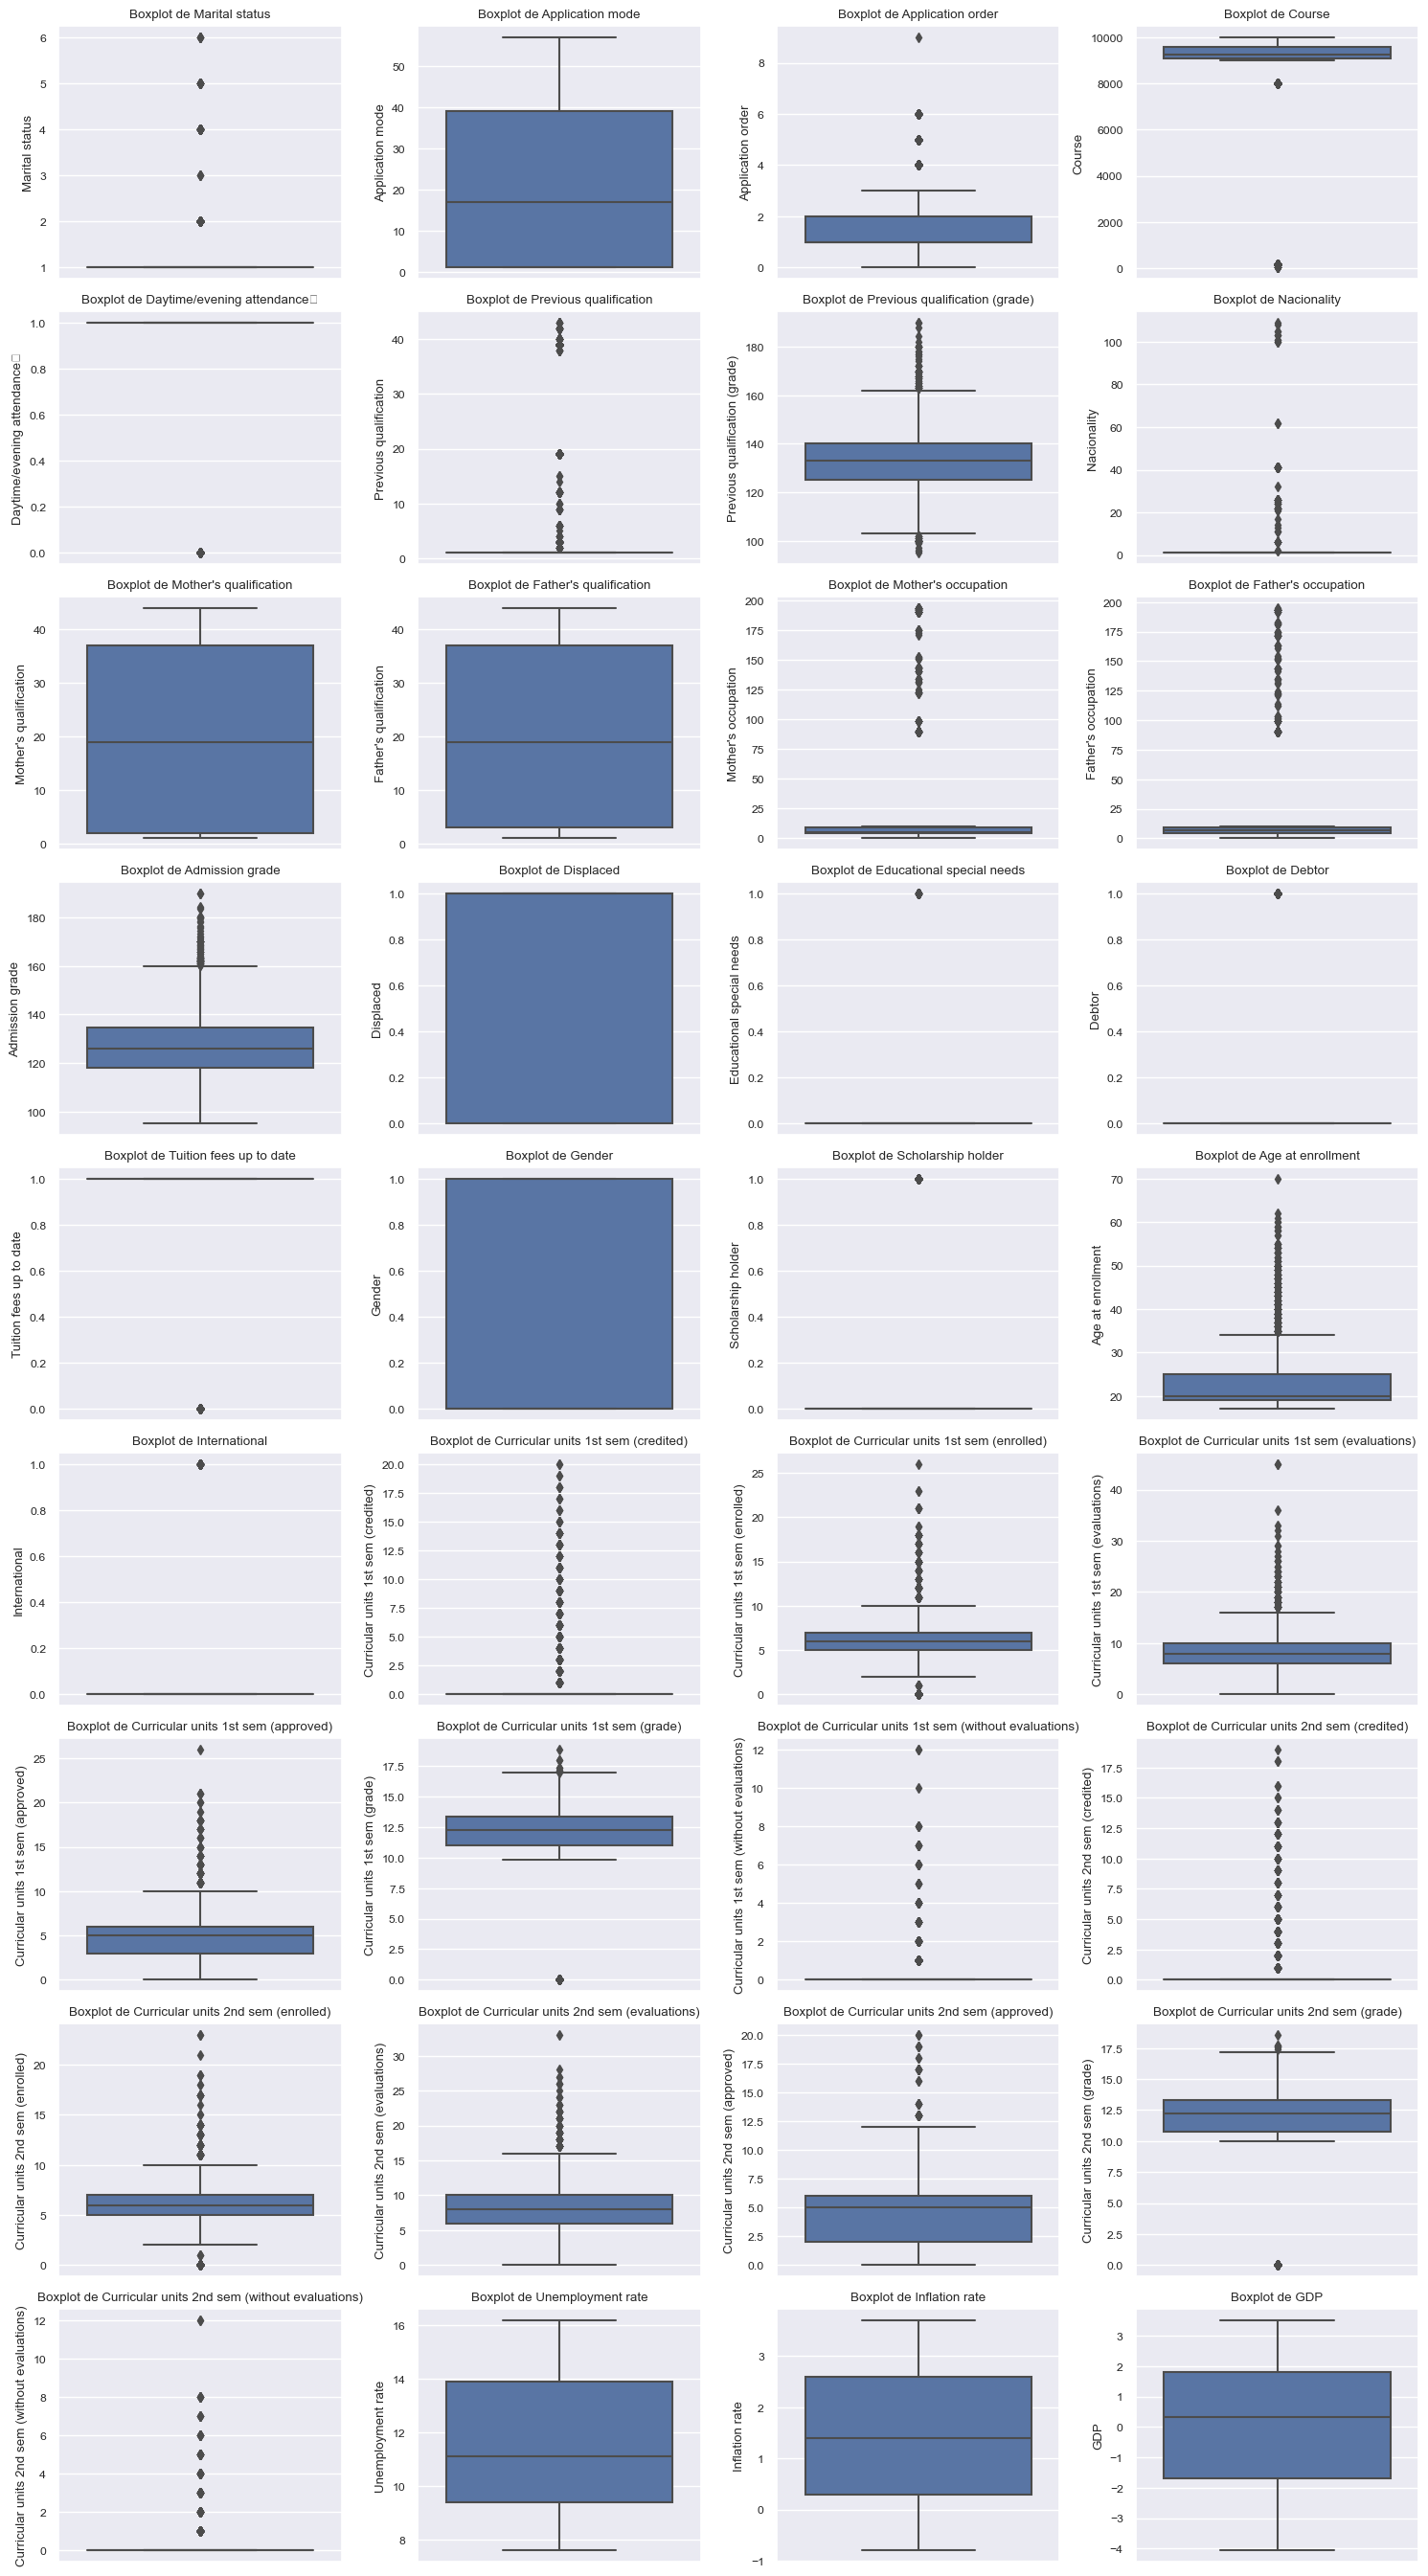

In [42]:
def plot_outliers(dataset, columns):
    n_cols = len(columns)
    n_rows = (n_cols + 3) // 4  
    plt.figure(figsize=(15, 3 * n_rows))
    
    for i, col in enumerate(columns):
        plt.subplot(n_rows, 4, i+1)
        sns.boxplot(y=dataset[col])
        plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
print(f"Número de columnas numéricas: {len(numeric_cols)}")
print("Columnas numéricas:", list(numeric_cols))
plot_outliers(dataset, numeric_cols)

Mediante estas gráficas podemos analizar el comportamiento de cada variable y observar quienes tienen visualmente una distribución normal o no y cómo están distribuidad.

En la variable género tiene una distribución equilibrada pues no hay un sesgo extremo de género.

En la edad al momento de la inscripción hay una mayor concentración en edades típicas entre los 18 a 20 años y pocos casos en edades mayores, siendo estudiantes no comunes entre los jóvenes o podría ser aquellos que están reingresando.

En estado civil predominan los estudiantes solteros y pocos casos de personas casadasu otras condiciones civiles.

En los desplazamientos hay una poca variabilidad, que puede señalar situaciones sociales extrernar que están afectando a algunos estudiantes.

En necesidades educativas especiales es una cantidad muy mínima pues estas medidas son poco relevantes en la universidad como algún tipo de inclusión o apoyo académico.

En los internaciones hay pocos estudiantes extranjeros.

En los deudores se presenta que la mayoría no tiene deudas, que podrían decir que hay poco riesgo de deserción pero sigue existiendo un grupo mínimo de estudiantes que tienen un índice grande de deudas. Y Matrículas actualizadas tiene la mayoría de estudiantes sus pagos al día y muy pocos, siendo algunos categorizados como deudores y con dificultades económicas.

Para los estudiantes becados se presenta una proporcón muy baja, por lo cual la mayoría de los estudiantes siguen dependiendo de los recursos propios para seguir estudiando

Para la variable en cuanto al primer semestre para aquellos aprobados se observa que la mayoría tiene una calificación alta en las materias aprobadas y muy pocos valores bajos pero da un riesgo de deserción que puede ser el descenso de algunos   estudiantes en épocas muy tempranas. En las notas se presententan algunas medias y altas, pero con una dispersión que refleja diferencias en el rendimiento. Y los NO evaluados se ve que todos los estudiantes tienen evaluaciones registradas y pocos que, por decirlo así, no las hicieron o no pudieron hacerlas, que puede reflejar abandono de los estudios.

Para la variable en cuanto al segundo semestre para aquellos aprobados tiene una tendencia similar al primer semestre pero con una caída en los valores altos, que puede ser un aumento de dificultades con el tiempo de entrega debido al atrazo del primer semestre. En las notas se presentan una distribución parecida a la del primer semestre, pero con más dispersión en el rendimiento. Y lo NO evaluados tienen un mismo patrón que el primer semestre.

En el PBI tiene variaciones moderadas, puede decirse que en el país tuvo una economía nacional constante. En cuanto a las inflaciones si hay un ligero aumento que pudo tener un impacto en los costos educativos. Y en la tasa de desempleo hubo una variabilidad moderada que puede producir un cambio en la capacidad de pago de los estudiantes.

Con estas características en cuenta, verificamos normalidad de estos datos

In [43]:
from scipy.stats import kstest
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
results = []

for col in numeric_cols:
    data = dataset[col].dropna()  
    if len(data) > 0:  
        mean, std = data.mean(), data.std()
        ks_stat, p_value = kstest(data, 'norm', args=(mean, std))
        
        results.append({
            'Variable': col,
            'N muestras': len(data),
            'KS Statistic': ks_stat,
            'p-value': p_value,
            'Normal (α=0.05)': p_value > 0.05
        })
results_df = pd.DataFrame(results)
print("\n=== Resultados KS (Datos Originales, sin Imputación) ===")
print(results_df.to_string(index=False))
non_normal_vars = results_df[results_df['Normal (α=0.05)'] == False]['Variable'].tolist()
print("\nVariables NO normales (p < 0.05):", non_normal_vars)



=== Resultados KS (Datos Originales, sin Imputación) ===
                                      Variable  N muestras  KS Statistic       p-value  Normal (α=0.05)
                                Marital status        4424      0.501775  0.000000e+00            False
                              Application mode        4424      0.229959 3.826259e-206            False
                             Application order        4424      0.394435  0.000000e+00            False
                                        Course        4424      0.428361  0.000000e+00            False
                  Daytime/evening attendance\t        4424      0.527670  0.000000e+00            False
                        Previous qualification        4424      0.477092  0.000000e+00            False
                Previous qualification (grade)        4424      0.090842  3.217270e-32            False
                                   Nacionality        4424      0.525382  0.000000e+00            False
      

Al ser los datos de nuestro dataset no normales, vamos a analizar cuales variables tienen una diferencia significativas entre sus grupos.

In [44]:
from scipy.stats import kruskal
results_kruskal = []
for col in numeric_cols:
    grupos = [dataset[dataset['Target'] == g][col].dropna() for g in dataset['Target'].unique()]
    if all(len(g) > 0 for g in grupos):
        stat, p = kruskal(*grupos)
        results_kruskal.append({
            'variable': col,
            'estadístico': stat,
            'p_value': p,
            'significativo': 'Sí' if p < 0.05 else 'No'
        })

kruskal_df = pd.DataFrame(results_kruskal)
print(kruskal_df)

                                          variable  estadístico  \
0                                   Marital status    57.253010   
1                                 Application mode   202.785714   
2                                Application order    47.303623   
3                                           Course     3.022211   
4                     Daytime/evening attendance\t    28.733441   
5                           Previous qualification    87.522904   
6                   Previous qualification (grade)    63.676925   
7                                      Nacionality     1.263301   
8                           Mother's qualification    12.248124   
9                           Father's qualification     4.832667   
10                             Mother's occupation     4.993452   
11                             Father's occupation     5.659176   
12                                 Admission grade    73.234687   
13                                       Displaced    57.74114

Al hacer este test identificamos que las variables con diferencias estadísticamente significativas son: Orden de aplicación, asistencia diurna/nocturna y las necesidades educativas especiales pues tienen valores casi cercanos a 0 y mucho menores que el nivel de significancia de la prueba. (1.595874e-03 ≈ 0.0016) - Diferencias significativas
Y para la variable de unidades curriculares de 1er semestre muestran valores muy altos, indicando grandes diferencias entre grupos en estas métricas.

Por ello, para el seguimiento de nuestro estudio, tendremos en cuenta estas variables para no llegar a un error de medición.

Ahora veremos un analisis de la correlación de nuestras variables:

Matriz de correlación: (36, 36)


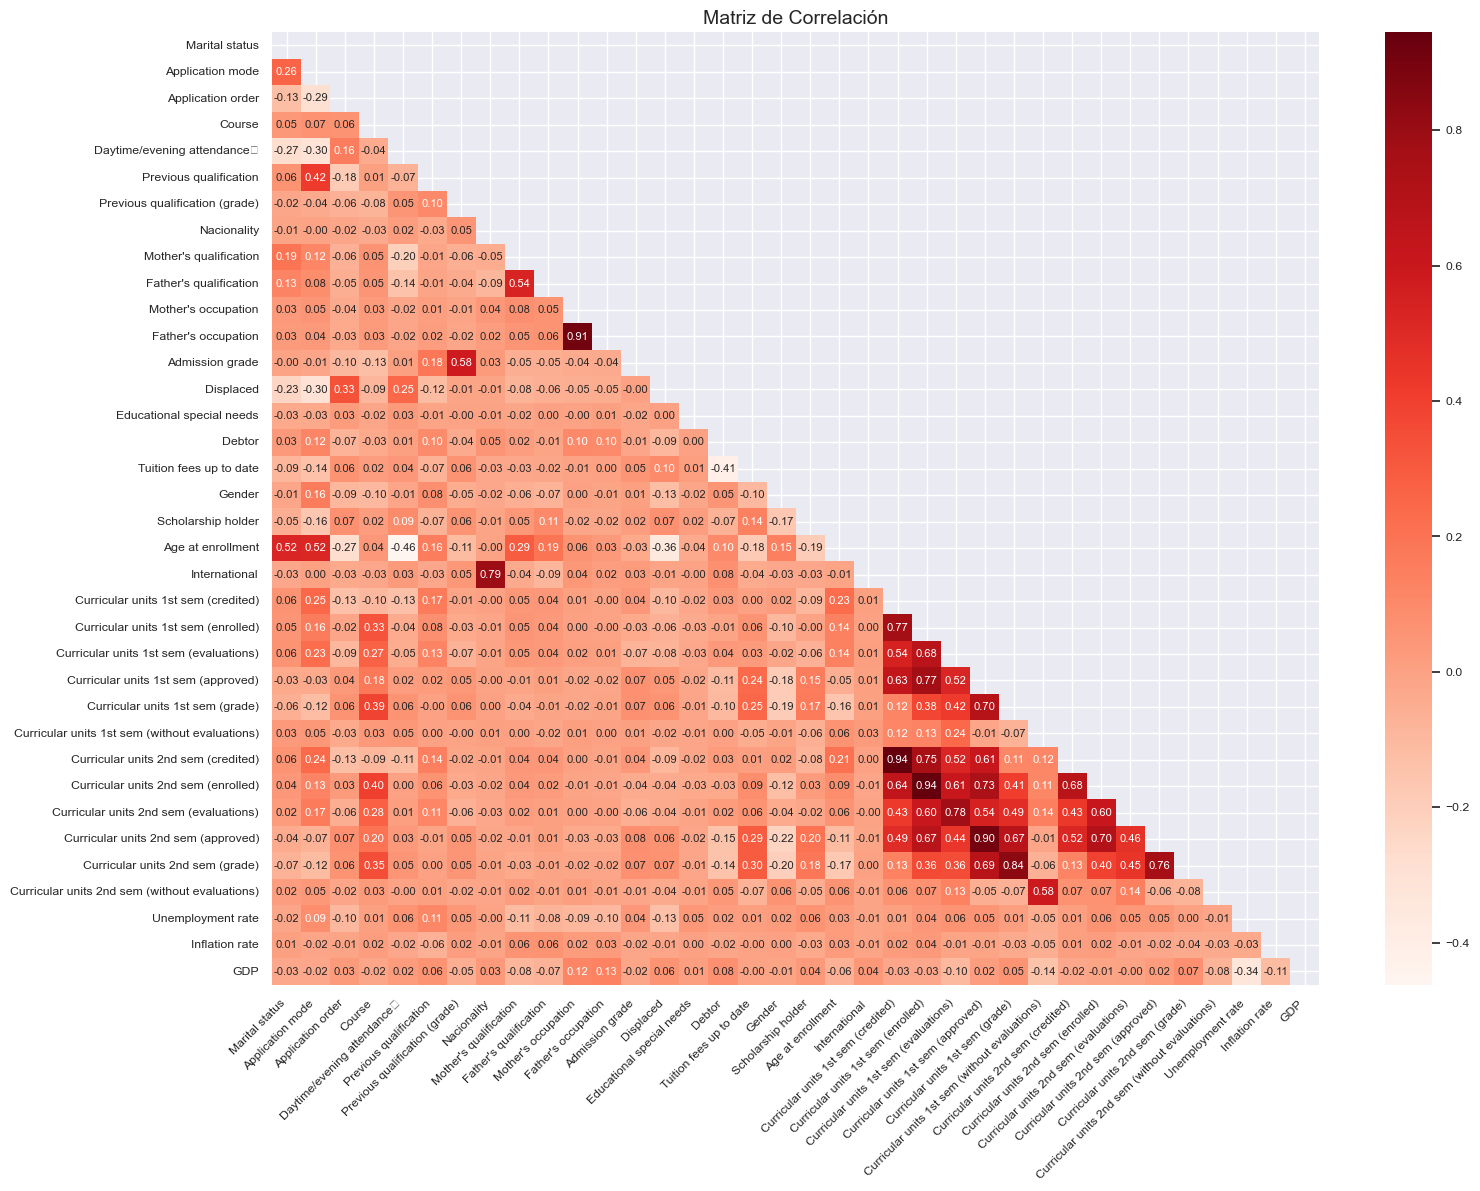

In [45]:
dataset_num = dataset.select_dtypes(include=np.number)
corr = dataset_num.corr()
print("Matriz de correlación:", corr.shape)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
plt.figure(figsize=(16, 12))  
sns.set(font_scale=0.8)       
sns.heatmap(
    corr, 
    mask=mask, 
    cmap='Reds', 
    annot=True, 
    fmt='.2f', 
    annot_kws={"size": 8},   
    cbar=True
)
plt.xticks(rotation=45, ha="right")  
plt.yticks(rotation=0)               
plt.title("Matriz de Correlación", fontsize=14)
plt.tight_layout()
plt.show()

Mediante esta matriz de correlación podemos interpretar, asignando grupos a las variables de acuerdo con su característica en común, que las variables académicas como inscripción, evaluaciones, aprobados y notas están muy relacionadas entre sí.

Para las variables tipo familiares, como género y las ocupaciones de los padres, muestran correlaciones altas entre s y reflejaría homogeneidad socioeconómica.

Mientras que en el caso contrario, siendo las relaciones negativas, se presentan en variables como becas y asistencia diurna/nocturna.

Y para las variables macroeconómicas, como la tasa de desempleo, la inflación y el PIB, muestran correlaciones bajas, teniendo poco impacto en las variables individuales de nuestra base de datos.

Mediante este análisis, calculamos el VIF para detectar si hay multicolinealidad en estos casos:

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from IPython.display import display
def VIF_calculation(X):
    VIF = pd.DataFrame()
    VIF["variable"] = X.columns
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    VIF = VIF.sort_values('VIF', ascending=False).reset_index(drop=True)
    return VIF
def delete_multicollinearity(df, target_name, VIF_threshold=10):
    X = df.drop(columns=[target_name])

    X = X.select_dtypes(include=[np.number])
    
    VIF_mat = VIF_calculation(X)
    n_VIF = VIF_mat["VIF"][0]

    if n_VIF <= VIF_threshold:
        print(" No hay multicolinealidad.")
    else:
        print(" Se detectó multicolinealidad. Eliminando variables...")
        while n_VIF > VIF_threshold:
            print(f"Eliminando '{VIF_mat['variable'][0]}' con VIF={n_VIF:.2f}")
            X = X.drop(columns=[VIF_mat["variable"][0]])
            VIF_mat = VIF_calculation(X)
            n_VIF = VIF_mat["VIF"][0]

    display(VIF_mat)
    return pd.concat([X, df[[target_name]]], axis=1)
df_copy = delete_multicollinearity(dataset, "Target", 10)

 Se detectó multicolinealidad. Eliminando variables...
Eliminando 'Curricular units 1st sem (enrolled)' con VIF=180.79
Eliminando 'Previous qualification (grade)' con VIF=129.64
Eliminando 'Curricular units 2nd sem (enrolled)' con VIF=50.74
Eliminando 'Admission grade' con VIF=43.84
Eliminando 'Curricular units 1st sem (approved)' con VIF=36.97
Eliminando 'Curricular units 2nd sem (grade)' con VIF=25.24
Eliminando 'Course' con VIF=23.20
Eliminando 'Unemployment rate' con VIF=18.77
Eliminando 'Curricular units 1st sem (evaluations)' con VIF=16.33
Eliminando 'Age at enrollment' con VIF=16.11
Eliminando 'Curricular units 1st sem (grade)' con VIF=14.75
Eliminando 'Curricular units 2nd sem (credited)' con VIF=10.60


,variable,VIF
0,Tuition fees up to date,8.699219
1,Daytime/evening attendance\t,8.115330
2,Curricular units 2nd sem (evaluations),7.362941
3,Father's occupation,7.070751
4,Mother's occupation,6.973680
5,Curricular units 2nd sem (approved),6.278566
6,Marital status,4.714827
7,Father's qualification,4.364045
8,Mother's qualification,3.759655
9,Application mode,3.243779


Mediante esta eliminación de las primeras variables con VIF extremadamente altos ayudó a identificar que estas aportan información muy redundante y hasta repetitiva, así no nos molestarían en cuanto a la revisión de los siguientes métodos que se implementan en este analisis. Entre esas eliminadas estaban las variables académicas del primer y segundo semestre que están altamente correlacionadas entre sí.

Y para las demás variables presentan en su mayoría un VIF entre 1 y 5, lo que indica baja multicolinealidad y mayor estabilidad para modelos predictivos.

Con ello, empezamos el analisis más profundo del proyecto integrador de aprendizaje automatizado. Los siguiente es isualizar la distribución de la variable Target.

Distribución de la variable target:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


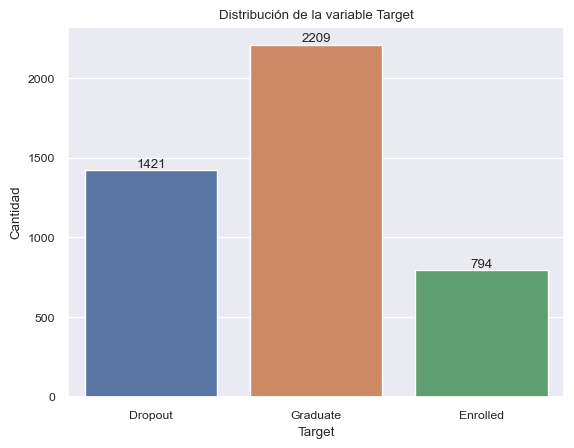

In [47]:
print("Distribución de la variable target:")
print(dataset['Target'].value_counts(normalize=True)*100)
ax = sns.countplot(x='Target', data=dataset)
plt.title('Distribución de la variable Target')
plt.xlabel('Target')
plt.ylabel('Cantidad')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')
plt.show()

Notamos que la distribución está desbalanceada y que predominan los graduados, pero el nivel de abandono, siendo casi un tercio, una cantidad alta en términos académicos y puede ser un riesgo importante pues es un hecho que el nivel de abandono puede llegar a un aumento significativo. 

Pudimos notar que casi la mitad de los estudiantes completan sus estudios y un 17.9% de estudiantes que sigue activo pero no ha graduado, lo cual afirma que hay un desbalance en los datos.

Y el menor porcentaje de estudiantes que siguen el cruzo en la universidad pueden ser aquellos estudiantes que ya finalizaron su carrera o estudio académico.

Con esto presente, haremos una indagación más profunda de estas caracteristicas utilizando RobustScaler:

In [48]:
from sklearn.preprocessing import RobustScaler
print("Escalado de características")
scaler = RobustScaler()
df_scaled = dataset.copy()
df_scaled[numeric_cols] = scaler.fit_transform(dataset[numeric_cols])
print("\nEstadísticas después de escalado (RobustScaler):")
print(df_scaled[numeric_cols].describe().T)

Escalado de características

Estadísticas después de escalado (RobustScaler):
                                                 count      mean        std  \
Marital status                                  4424.0  0.178571   0.605747   
Application mode                                4424.0  0.043923   0.460123   
Application order                               4424.0  0.727848   1.313793   
Course                                          4424.0 -0.809676   4.381245   
Daytime/evening attendance\t                    4424.0 -0.109177   0.311897   
Previous qualification                          4424.0  3.577758  10.216592   
Previous qualification (grade)                  4424.0 -0.032446   0.879222   
Nacionality                                     4424.0  0.873192   6.914514   
Mother's qualification                          4424.0  0.016055   0.445805   
Father's qualification                          4424.0  0.096333   0.451268   
Mother's occupation                             4424.

Esto nos ayudó a indentificar que los modelos sensibles a escalas, como k-NN ue vamos a construir y a ejecutar en este EDA, se van a beneficiar de este preprocesamiento.

También, como analizamos en puntos anteriores sobre los valores atípicos, esta prueba muestra que su no hace un impacto significativo en el estudio.

Algunas variables como curso, cualificaciones previas y unidades curriculaes tienen una variabilidad notable, por lo que puede darles más peso en el modelo que no usan regularización fuerte. Y las variables binarias muestran rangos acotados, así que no se distorsionan.

In [49]:
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
target_encoded = dataset['Target'].astype('category').cat.codes

mi_scores = mutual_info_classif(dataset[numeric_cols], target_encoded, random_state=42)
mi_dataset = pd.DataFrame({'Variable': numeric_cols, 'MI_Score': mi_scores})
mi_dataset = mi_dataset.sort_values('MI_Score', ascending=False)

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(dataset[numeric_cols], target_encoded)
anova_df = pd.DataFrame({'Variable': numeric_cols, 'F_Score': selector.scores_})
anova_df = anova_df.sort_values('F_Score', ascending=False)

feature_importance = mi_dataset.merge(anova_df, on='Variable')
feature_importance['Combined_Score'] = (feature_importance['MI_Score'] + 
                                      feature_importance['F_Score']/feature_importance['F_Score'].max())
feature_importance = feature_importance.sort_values('Combined_Score', ascending=False)

print("\nVariables predictoras más importantes:")
print(feature_importance.head(15))


Variables predictoras más importantes:
                                  Variable  MI_Score      F_Score  \
0      Curricular units 2nd sem (approved)  0.310207  1410.732938   
1         Curricular units 2nd sem (grade)  0.239324  1134.109544   
2      Curricular units 1st sem (approved)  0.233439   859.866768   
3         Curricular units 1st sem (grade)  0.184882   713.517328   
4                  Tuition fees up to date  0.100460   505.621429   
14                      Scholarship holder  0.037139   225.751437   
7                        Age at enrollment  0.065516   154.712071   
5   Curricular units 2nd sem (evaluations)  0.096761    87.801092   
15                                  Debtor  0.033628   137.647527   
10                        Application mode  0.046571   114.534956   
18                                  Gender  0.024435   123.041811   
6   Curricular units 1st sem (evaluations)  0.075691    37.527840   
12     Curricular units 2nd sem (enrolled)  0.041576    75.5919

Mediante este análisis pudimos encontrar que las variables tipo académicas son los mejores predictores, pues entre estas variables como el rendimiento en unidades curriculares de 1er y 2do semestre es el factor más predictivo, así como las notas y el número de asignaturas aprobadas, cumpliendo así lo mostrado en la matriz de correlación.

Entre las variables financieras como la matrícula actualizada y los becados tienen impacto moderado, mientras que el deudor tiene menor importancia, lo cual parece extraño pues son las principales causas de la deserción, pero por ser aquellos porcentajes amplios, se siguen teniendo en la lista

Y una característica encontrada para la variable del historial académico previo aparece como el factor menos importante entre los listados pues no es usado como una medida estandar luego de ser el estudiante admitido pues antes de la admisión se evalua este historial, y siendo que el estudiante está dentro de la insititución, se deduce que cumplió los requisitos. Por tanto esta variable tiene un menor uso.

Mediante este analisis del top 10 de las variables predictoras pudimos notar que para la unidad curricular del 2do semestre y sus desertores aprueban menos unidades en el segundo semestre. Los graduados y inscritos tienen un desempeño similar perolos graduados aprueban más. En cuanto a las notas, los desertores muestran que los estudiantes tienen calificaciones más bajas y los graduados obtienen las notas más altas, al igual que los inscritos.

Mientras que los de 1er semestre tienen una misma tendencia que en el segundo semestre pero los graduados tienen mejores resultados pues participan más en evaluaciones, reflejando mayor compromiso, mientras que los desertores también tienen calificaciones más bajas desde el primer semestre.

En los becados vemos que solo los graduados tienen becas y eso influye en tener más éxito académico. También los graduados e inscritos son generalmente más jóvenes, por lo que podríamos deducir que entre más joven, más permanencia en la universidad.

Por ello, podemos decir que los desertores tienen las siguientes caracteristicas:

- Pocas unidades aprobadas y bajas calificaciones.

- No estar al día con las cuotas.

- No tienen beca.

- Algunos tienen una edad avanzada.

- Tienen enor número de evaluaciones rendidas.

Mientras que los mejores graduados tienen lo siguiente: 

- Buen rendimiento académico.

- Becados.

- La mayoría son jovenes al momento del ingreso.

- Cuotas al día.

- Participación activa en evaluaciones.

Análisis Bivariado Avanzado


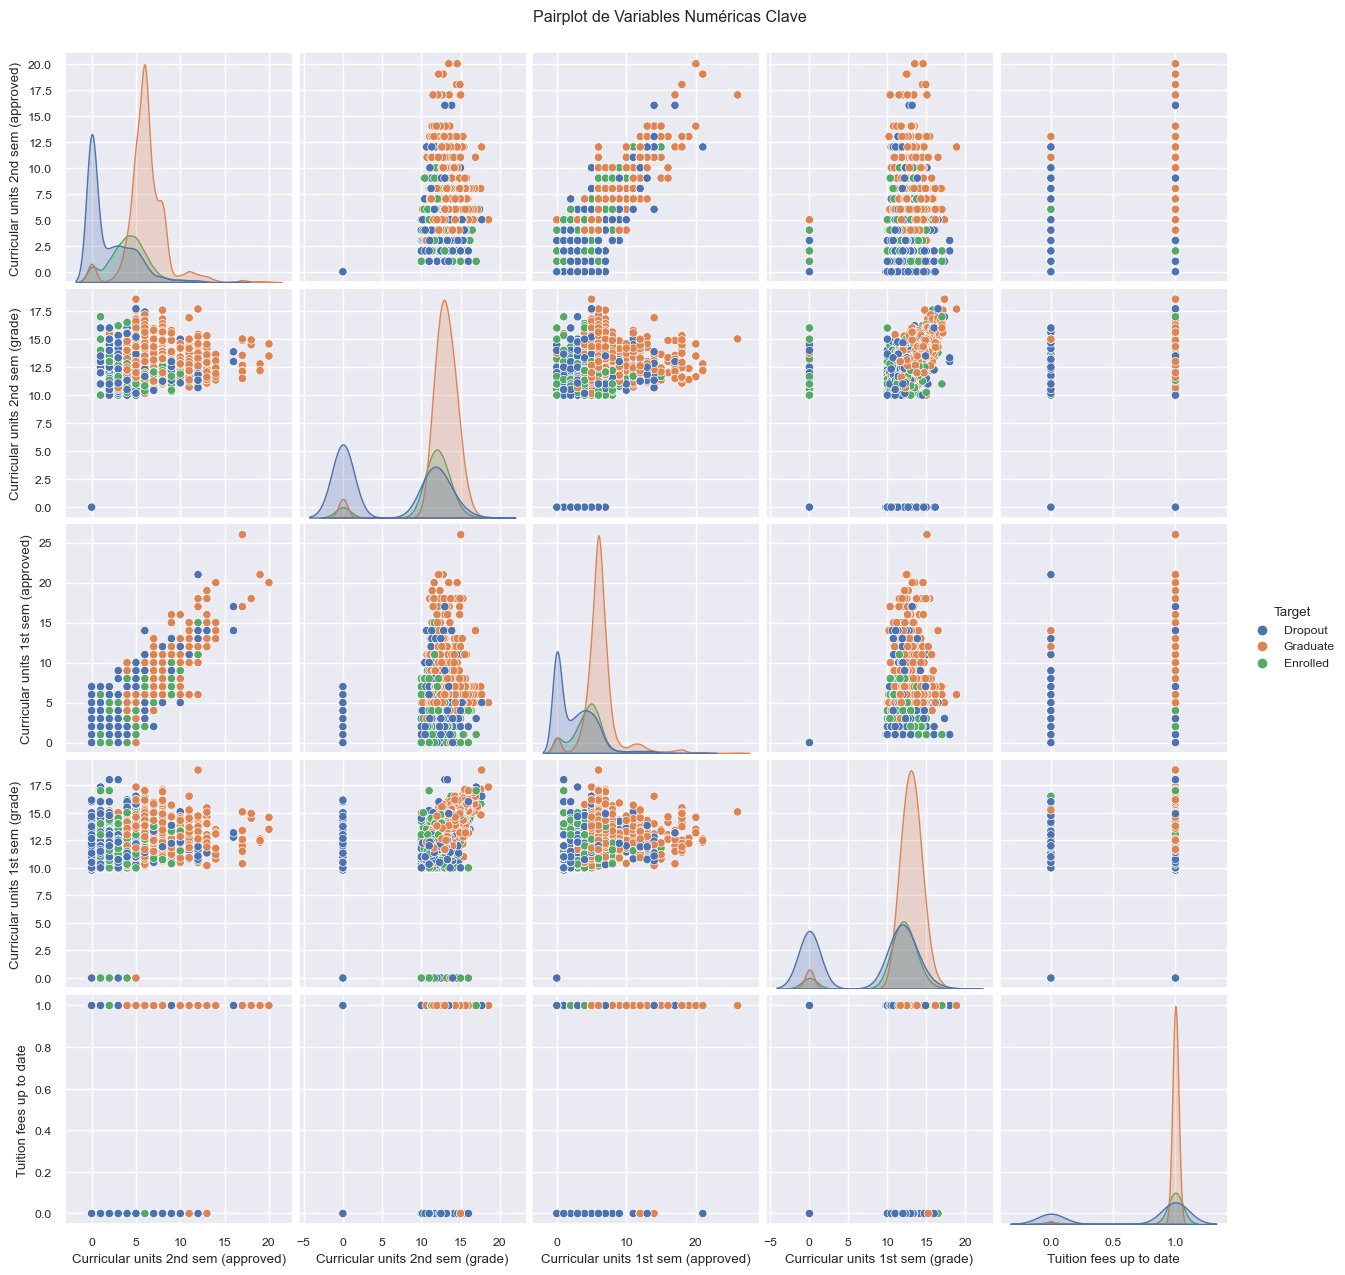

Correlación entre Variables Clave y Target (codificado)


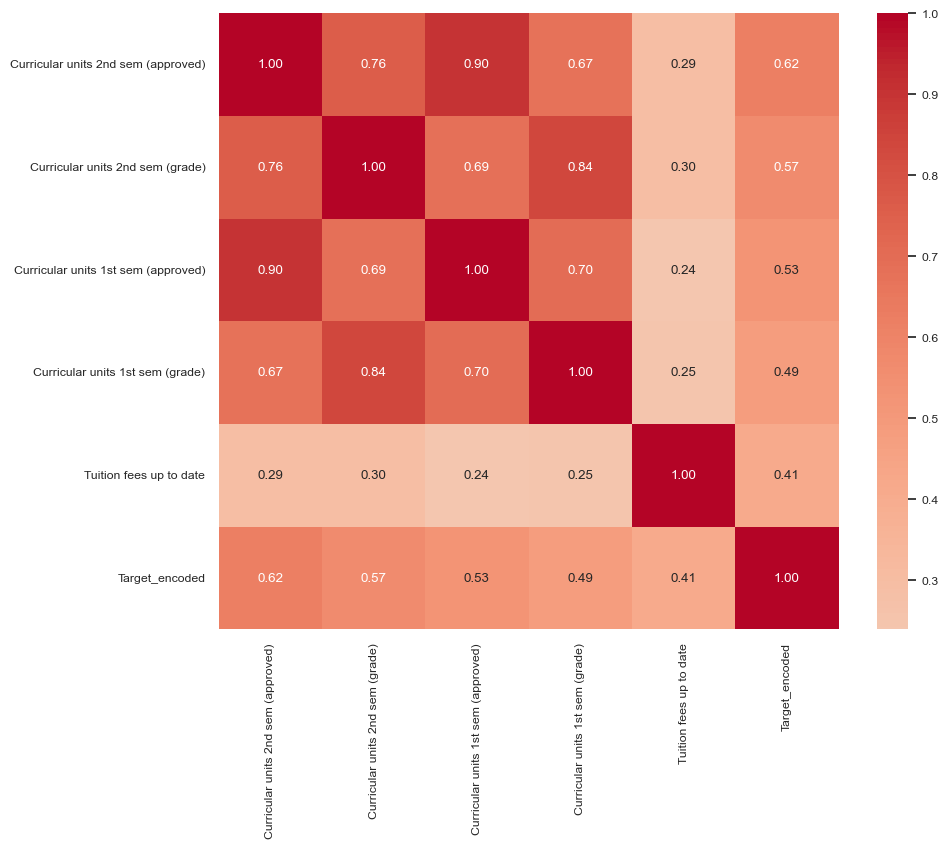

In [50]:
print("Análisis Bivariado Avanzado")
top_features = feature_importance['Variable'].head(10).tolist()
top_numeric = [f for f in top_features if f in numeric_cols][:5]

if top_numeric:
    sns.pairplot(data=dataset, vars=top_numeric, hue='Target')
    plt.suptitle('Pairplot de Variables Numéricas Clave', y=1.02)
    plt.show()

    print("Correlación entre Variables Clave y Target (codificado)")
    if 'Target' in dataset.select_dtypes(include=['number']).columns:
        corr_data = dataset[top_numeric + ['Target']]
    else:
        corr_data = dataset[top_numeric].join(target_encoded.rename('Target_encoded'))
    
    top_corr = corr_data.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(top_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.show()
else:
    print("No se encontraron variables numéricas entre las características seleccionadas.")

Mediante este analisis bivariado pudimos notar que para la unidad curricular del 2do semestre y sus desertores aprueban menos unidades en el segundo semestre. Los graduados y inscritos tienen un desempeño similar perolos graduados aprueban más. En cuanto a las notas, los desertores muestran que los estudiantes tienen calificaciones más bajas y los graduados obtienen las notas más altas, al igual que los inscritos.

Mientras que los de 1er semestre tienen una misma tendencia que en el segundo semestre pero los graduados tienen mejores resultados pues participan más en evaluaciones, reflejando mayor compromiso, mientras que los desertores también tienen calificaciones más bajas desde el primer semestre.

En los becados vemos que solo los graduados tienen becas y eso influye en tener más éxito académico. También los graduados e inscritos son generalmente más jóvenes, por lo que podríamos deducir que entre más joven, más permanencia en la universidad.

Por ello, podemos decir que los desertores tienen las siguientes caracteristicas:

- Pocas unidades aprobadas y bajas calificaciones.

- No estar al día con las cuotas.

- No tienen beca.

- Algunos tienen una edad avanzada.

- Tienen enor número de evaluaciones rendidas.

Mientras que los mejores graduados tienen lo siguiente: 

- Buen rendimiento académico.

- Becados.

- La mayoría son jovenes al momento del ingreso.

- Cuotas al día.

- Participación activa en evaluaciones.

Y observando la correlación entre variables clave y Target pudimos deducir que los estudiantes que aprueban más materias también obtienen mejores calificaciones y el rendimiento en el primer semestre predice el del segundo. También los  aprobados y las calificaciones del segundo semestre son los predictores más fuertes del éxito, es decir, más prpensos a graduarse.

Ahora seguimos con el análisis de Regresión de Clasificación

k=1 -> Accuracy CV promedio: 0.8049
k=2 -> Accuracy CV promedio: 0.7787
k=3 -> Accuracy CV promedio: 0.8337
k=4 -> Accuracy CV promedio: 0.8198
k=5 -> Accuracy CV promedio: 0.8330
k=6 -> Accuracy CV promedio: 0.8346
k=7 -> Accuracy CV promedio: 0.8359
k=8 -> Accuracy CV promedio: 0.8395
k=9 -> Accuracy CV promedio: 0.8343
k=10 -> Accuracy CV promedio: 0.8379
k=11 -> Accuracy CV promedio: 0.8349
k=12 -> Accuracy CV promedio: 0.8372
k=13 -> Accuracy CV promedio: 0.8340
k=14 -> Accuracy CV promedio: 0.8379
k=15 -> Accuracy CV promedio: 0.8317
k=16 -> Accuracy CV promedio: 0.8372
k=17 -> Accuracy CV promedio: 0.8311
k=18 -> Accuracy CV promedio: 0.8362
k=19 -> Accuracy CV promedio: 0.8333

Mejor k encontrado: 8 con accuracy promedio CV: 0.8395

Accuracy en test: 0.8381024096385542

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.60      0.71       427
           1       0.83      0.95      0.89       901

    accuracy           

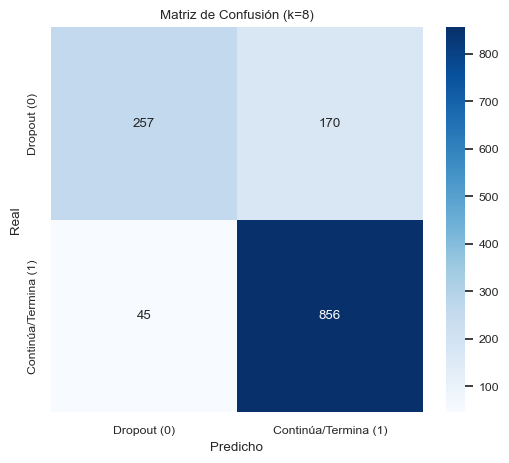

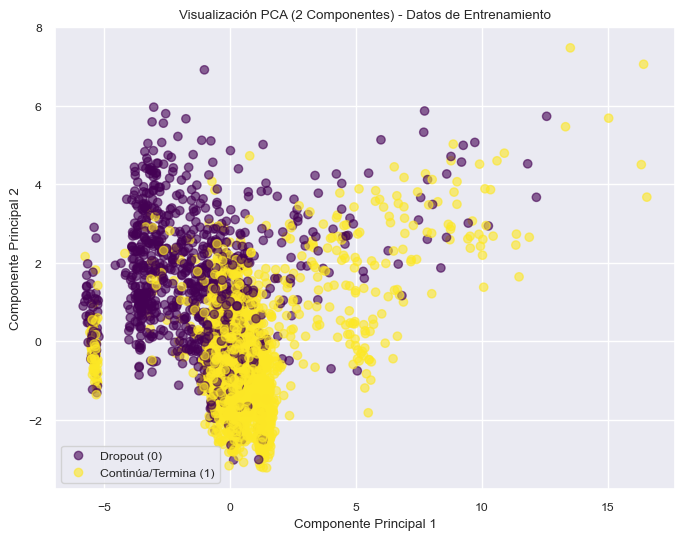

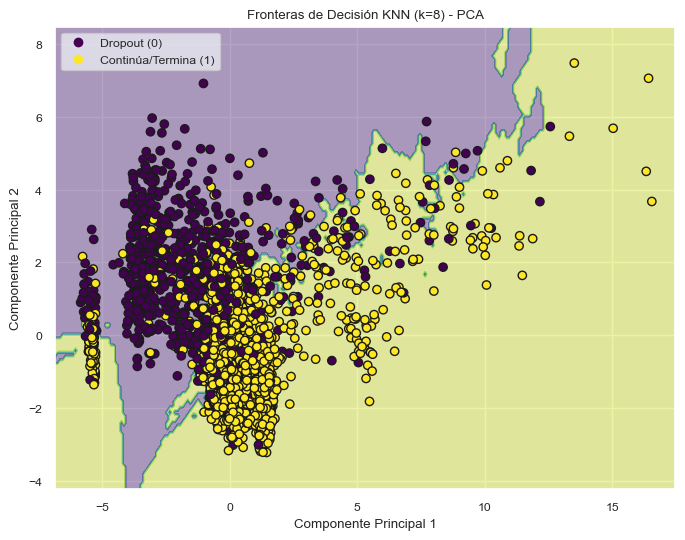

In [51]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.decomposition import PCA
from scipy.sparse import issparse
categorical_nominal = [
    'Marital status', 'Application mode', 'Course', 'Nacionality',
    "Mother's occupation", "Father's occupation"
]
for col in categorical_nominal:
    dataset[col] = dataset[col].astype(str)

dataset['Target_binary'] = dataset['Target'].apply(lambda x: 0 if x == 'Dropout' else 1)


X = dataset.drop(['Target', 'Target_binary'], axis=1)
y = dataset['Target_binary']

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_nominal)
    ],
    remainder='passthrough'  
)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_values = range(1, 20)
mean_scores = []

for k in k_values:
    scores = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        
        X_tr_processed = preprocessor.fit_transform(X_tr)
        X_val_processed = preprocessor.transform(X_val)

        
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr_processed, y_tr)

        
        y_val_pred = knn.predict(X_val_processed)

        
        acc = accuracy_score(y_val, y_val_pred)
        scores.append(acc)

    mean_score = np.mean(scores)
    mean_scores.append(mean_score)
    print(f"k={k} -> Accuracy CV promedio: {mean_score:.4f}")

best_k = k_values[np.argmax(mean_scores)]
print(f"\nMejor k encontrado: {best_k} con accuracy promedio CV: {max(mean_scores):.4f}")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


if issparse(X_train_processed):
    X_train_processed = X_train_processed.toarray()
if issparse(X_test_processed):
    X_test_processed = X_test_processed.toarray()

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_processed, y_train)


y_pred = knn_final.predict(X_test_processed)
print("\nAccuracy en test:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout (0)', 'Continúa/Termina (1)'],
            yticklabels=['Dropout (0)', 'Continúa/Termina (1)'])
plt.title(f"Matriz de Confusión (k={best_k})")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_processed)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.title('Visualización PCA (2 Componentes) - Datos de Entrenamiento')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Dropout (0)', 'Continúa/Termina (1)'])
plt.show()

def plot_decision_boundaries(X_pca, y, k):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_pca, y)
    
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
    plt.title(f'Fronteras de Decisión KNN (k={k}) - PCA')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.legend(handles=scatter.legend_elements()[0],
               labels=['Dropout (0)', 'Continúa/Termina (1)'])
    plt.show()

plot_decision_boundaries(X_train_pca, y_train, best_k)

Los resultados arrojados en este estudio recalca nuevamente que existe una correlación entre variables y el target.
Mediante estos datos resultantes como:

- Curricular units 2nd sem (approved): 0.62

- Curricular units 2nd sem (grade): 0.57

- Curricular units 1st sem (approved): 0.53

- Curricular units 1st sem (grade): 0.49

- Tuition fees up to date: 0.41

Indica que las notas y materias aprobadas son buenos predictores del abandono o continuidad.

En la evaluación del modelo KNN evaluamos varios valores de k de 1 a 19 con validación cruzada y el mejor resultado se obtuvo con k=8, con un accuracy promedio de 0.8395 y una accuracy en el conjunto de test: 0.8381. Esto da a entender ue hay un buen rendimiento del modelo con un 84% de precisión en predicción.

En la aatriz de confusión tenemos que los verdaderos positivos, siendo de 856, predijo que estudiantes continuarían y fue cierto, los falsos positivos, siendo de 45, predijo que estudiantes continuarían pero abandonaron, los falsos negativos, siendo de 170, predijo que estudiantes abandonarían pero continuaron, y los verdaderos negativos, siendo de 257, predijo el abandono de estudiantes.

Por ello, este modelo predice mejor la continuidad estudiantil que el abandono, pues las clases están desbalanceadas.


En el gráfico de dispersión se observa una separación entre los desertores (color morado) y los que continuan con sus estudios (color amarillo). 

Y en la segunda gráfica de PCA donde se muestra las regiones de decisión generadas por KNN logra una separación entre las clases, por lo que los datos muestran cierta separación entre quienes abandonan y quienes continúan.

Columnas disponibles: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP',

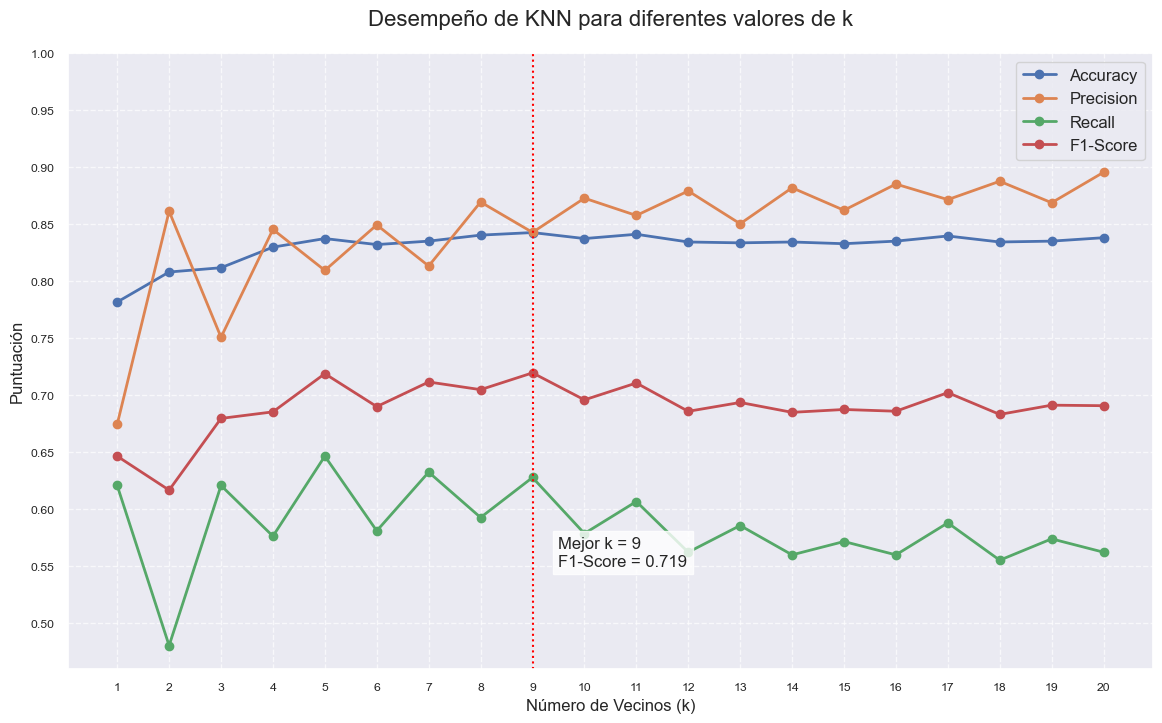


Reporte de Clasificación (k = 9):
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       901
           1       0.84      0.63      0.72       427

    accuracy                           0.84      1328
   macro avg       0.84      0.79      0.81      1328
weighted avg       0.84      0.84      0.84      1328


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       901
           1       0.84      0.63      0.72       427

    accuracy                           0.84      1328
   macro avg       0.84      0.79      0.81      1328
weighted avg       0.84      0.84      0.84      1328



In [52]:
dataset['abandona'] = dataset['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
print("Columnas disponibles:", dataset.columns.tolist())
variables = [
    'Marital status', 
    'Application mode', 
    'Application order',
    'Course', 
    'Daytime/evening attendance',  
    'Previous qualification',
    'Previous qualification (grade)', 
    'Admission grade', 
    'Age at enrollment',
    'Curricular units 1st sem (credited)', 
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)']
def find_column(possible_names, df_columns):
    for name in possible_names:
        for col in df_columns:
            if name.lower().replace(' ', '') in col.lower().replace(' ', ''):
                return col
    return None
real_columns = []
for var in variables:
    col = find_column([var, var.replace(' ', '_'), var.replace(' ', '')], dataset.columns)
    if col is not None:
        real_columns.append(col)
    else:
        print(f"No se encontró columna para '{var}'")

df = dataset[real_columns].copy()
df.columns = [col.lower().replace(' ', '_').replace('(', '').replace(')', '') for col in df.columns]

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
X = df  
y = dataset['abandona']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_cols, index=X_test.index)

k_values = range(1, 21)
metrics = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for k in k_values:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    
    metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['Precision'].append(precision_score(y_test, y_pred))
    metrics['Recall'].append(recall_score(y_test, y_pred))
    metrics['F1-Score'].append(f1_score(y_test, y_pred))

best_k = k_values[np.argmax(metrics['F1-Score'])]
best_k2 = k_values[np.argmax(mean_scores)]
print(f"\nMejor valor de k: {best_k}")
print(f"\nMejor valor de k: {best_k2}")

plt.figure(figsize=(14, 8))

for metric_name, values in metrics.items():
    plt.plot(k_values, values, marker='o', label=metric_name, linewidth=2)

plt.title('Desempeño de KNN para diferentes valores de k', fontsize=16, pad=20)
plt.xlabel('Número de Vecinos (k)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.xticks(k_values)
plt.yticks(np.arange(0.5, 1.01, 0.05))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

best_score = max(metrics['F1-Score'])
plt.axvline(x=best_k, color='red', linestyle=':', linewidth=1.5)
plt.text(best_k+0.5, 0.55, f'Mejor k = {best_k}\nF1-Score = {best_score:.3f}', 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("\nReporte de Clasificación (k = {}):".format(best_k))
print(classification_report(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Mejor valor de k: 9


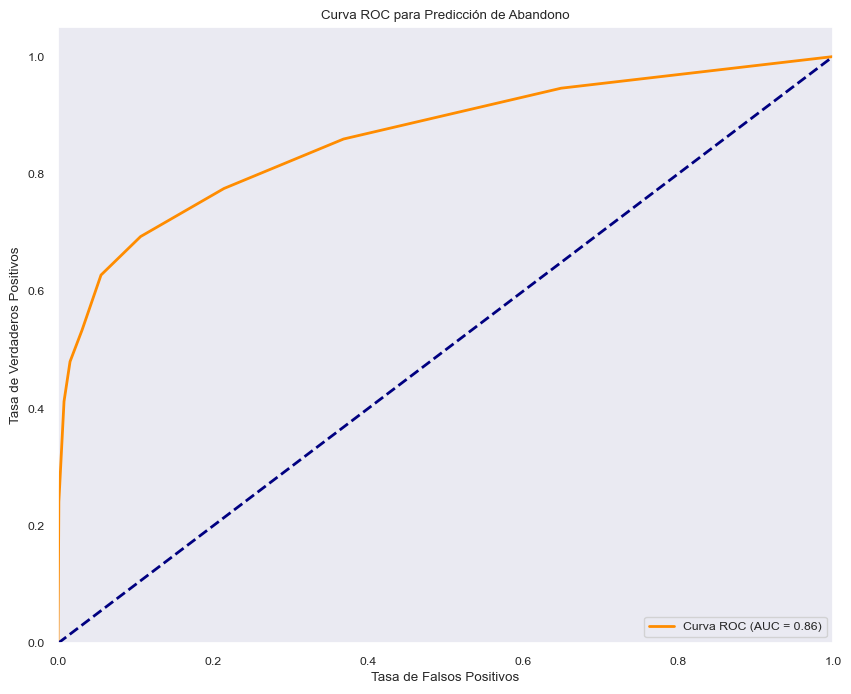

In [53]:
from sklearn.metrics import roc_curve, auc
k_values = range(1, 21)
accuracy_scores = []
for k in k_values:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))
best_k = k_values[np.argmax(accuracy_scores)]
print(f"\nMejor valor de k: {best_k}")
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Predicción de Abandono')
plt.legend(loc="lower right")
plt.grid()
plt.show()


Algunos hallazgos que encontramos en estas gráficas es la presencia de falsos Negativos altos, con una cantidad  171 estudiantes en riesgo no detectados. Y en falsos Positivos bajos solo 45 estudiantes podrían recibir ayuda innecesaria.

También para nuestro gráfico ROC tenemos un AUC = 0.87, por lo que el modelo distingue bien entre clases.

Para nuestro gráfico de dispersión (Real vs. Predicho) notamos puntos que  se alinean cerca de la diagonal por lo que hace que las predicciones sean más precisas. Hay presencia de pocos outliers como por ejemplo estudiantes con notas reales altas pero predichas como bajas.
Tienen una istribución simétrica alrededor de 0, por lo que no hay sesgo claro y una heterocedasticidad leve pues hay una mayor varianza en notas altas.

El modelo es efectivo pues ayuda a identificar estudiantes que continuarán, identificar estudiantes en riesgo para brindar apoyo académico y priorizar ayuda a estudiantes con mayor probabilidad de abandono.


In [54]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier

def manual_cv_knn_classification(X, y, k_list=range(1,21), n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []

    for k in k_list:
        accs, precs, recs, f1s, rocs = [], [], [], [], []
        for train_idx, val_idx in skf.split(X, y):
            X_train_fold = X.iloc[train_idx].copy()
            X_val_fold = X.iloc[val_idx].copy()
            y_train_fold = y.iloc[train_idx]
            y_val_fold = y.iloc[val_idx]

            # escalo numéricas (fit solo con train)
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train_fold[numeric_cols])
            X_val_num = scaler.transform(X_val_fold[numeric_cols])

            # one-hot para categóricas (fit solo con train)
            if len(categorical_cols) > 0:
                ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
                X_train_cat = ohe.fit_transform(X_train_fold[categorical_cols])
                X_val_cat = ohe.transform(X_val_fold[categorical_cols])
                X_train_proc = np.hstack([X_train_num, X_train_cat])
                X_val_proc = np.hstack([X_val_num, X_val_cat])
            else:
                X_train_proc = X_train_num
                X_val_proc = X_val_num

            # entreno KNN
            clf = KNeighborsClassifier(n_neighbors=k)
            clf.fit(X_train_proc, y_train_fold)
            y_pred = clf.predict(X_val_proc)

            # probabilidades para ROC AUC (si hay ambas clases)
            try:
                y_proba = clf.predict_proba(X_val_proc)[:,1]
                roc = roc_auc_score(y_val_fold, y_proba)
            except Exception:
                roc = np.nan

            accs.append(accuracy_score(y_val_fold, y_pred))
            precs.append(precision_score(y_val_fold, y_pred, zero_division=0))
            recs.append(recall_score(y_val_fold, y_pred, zero_division=0))
            f1s.append(f1_score(y_val_fold, y_pred, zero_division=0))
            rocs.append(roc)

        results.append({
            'k': k,
            'accuracy_mean': np.mean(accs),
            'accuracy_std': np.std(accs),
            'precision_mean': np.mean(precs),
            'recall_mean': np.mean(recs),
            'f1_mean': np.mean(f1s),
            'roc_mean': np.nanmean(rocs)  # puede haber NaN si alguna fold no tienen ambas clases
        })

    return pd.DataFrame(results)

# correr validación manual
k_candidates = range(1,21)
cv_results = manual_cv_knn_classification(X, y, k_list=k_candidates, n_splits=5)
cv_results = cv_results.sort_values('f1_mean', ascending=False).reset_index(drop=True)
cv_results.head(10)

best_by_f1 = int(cv_results.sort_values('f1_mean', ascending=False).iloc[0]['k'])
best_by_recall = int(cv_results.sort_values('recall_mean', ascending=False).iloc[0]['k'])
best_by_accuracy = int(cv_results.sort_values('accuracy_mean', ascending=False).iloc[0]['k'])

print("Mejor k por F1:", best_by_f1, "por Recall:", best_by_recall, "por Accuracy:", best_by_accuracy)

# ahora entreno con la partición train/test tradicional para reportar (sin Pipeline)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# preparo transformaciones usando solo X_train
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_test_num = scaler.transform(X_test[numeric_cols])

if len(categorical_cols) > 0:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
    X_train_cat = ohe.fit_transform(X_train[categorical_cols])
    X_test_cat = ohe.transform(X_test[categorical_cols])
    X_train_proc = np.hstack([X_train_num, X_train_cat])
    X_test_proc = np.hstack([X_test_num, X_test_cat])
else:
    X_train_proc = X_train_num
    X_test_proc = X_test_num

# uso best_k según criterio (aquí elijo F1)
chosen_k = best_by_f1
knn_final = KNeighborsClassifier(n_neighbors=chosen_k)
knn_final.fit(X_train_proc, y_train)
y_pred = knn_final.predict(X_test_proc)
y_proba = knn_final.predict_proba(X_test_proc)[:,1]

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def manual_cv_knn_regression(X, y_reg, k_list=range(1,21), n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []
    # asumimos regresión sobre variables numéricas solo (o manejamos categóricas con OHE igual que arriba)
    # para no complicar, escalo numéricas y hago OHE si hay categóricas
    for k in k_list:
        maes, rmses, r2s = [], [], []
        for train_idx, val_idx in kf.split(X):
            X_train_fold = X.iloc[train_idx].copy()
            X_val_fold = X.iloc[val_idx].copy()
            y_train_fold = y_reg.iloc[train_idx]
            y_val_fold = y_reg.iloc[val_idx]

            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train_fold[numeric_cols])
            X_val_num = scaler.transform(X_val_fold[numeric_cols])

            if len(categorical_cols) > 0:
                ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
                X_train_cat = ohe.fit_transform(X_train_fold[categorical_cols])
                X_val_cat = ohe.transform(X_val_fold[categorical_cols])
                X_train_proc = np.hstack([X_train_num, X_train_cat])
                X_val_proc = np.hstack([X_val_num, X_val_cat])
            else:
                X_train_proc = X_train_num
                X_val_proc = X_val_num

            reg = KNeighborsRegressor(n_neighbors=k)
            reg.fit(X_train_proc, y_train_fold)
            y_pred = reg.predict(X_val_proc)

            maes.append(mean_absolute_error(y_val_fold, y_pred))
            rmses.append(np.sqrt(mean_squared_error(y_val_fold, y_pred)))
            r2s.append(r2_score(y_val_fold, y_pred))

        results.append({
            'k': k,
            'mae_mean': np.mean(maes),
            'rmse_mean': np.mean(rmses),
            'r2_mean': np.mean(r2s)
        })
    return pd.DataFrame(results)

# ejemplo de uso para la columna 'curricular_units_2nd_sem_grade' si existe
target_reg_col = 'curricular_units_2nd_sem_grade'
if target_reg_col in dataset.columns:
    y_reg = dataset[target_reg_col]
    X_reg = dataset.drop(columns=[target_reg_col] + drop_cols, errors='ignore')
    numeric_cols_reg = X_reg.select_dtypes(include=[np.number]).columns.tolist()
    # reuso categorical_cols si aplica
    numeric_cols_saved = numeric_cols  # guardo por si lo necesito
    numeric_cols = numeric_cols_reg    # la función usa esta variable global; o adapta para pasar como arg
    reg_results = manual_cv_knn_regression(X_reg, y_reg, k_list=range(1,21), n_splits=5)
    print(reg_results.sort_values('rmse_mean').head())
else:
    print("No se encontró la columna para regresión:", target_reg_col)

# ---- Validación manual KNN (clasificación) - SIN dependencias extra ----
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, mean_absolute_error,
                             mean_squared_error, r2_score, roc_curve, auc)

# detecto columnas numéricas y categóricas (ajusta si quieres columnas explícitas)
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object','category']).columns.tolist()

def manual_cv_knn_classification(X, y, k_list=range(1,21), n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []
    for k in k_list:
        accs, precs, recs, f1s, rocs = [], [], [], [], []
        for train_idx, val_idx in skf.split(X, y):
            X_train = X.iloc[train_idx].copy()
            X_val = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            # escalo numéricas (fit en train)
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_cols])
            X_val_num = scaler.transform(X_val[numeric_cols])

            # encoding con pandas.get_dummies por fold (fit en train)
            if len(categorical_cols) > 0:
                X_train_cat = pd.get_dummies(X_train[categorical_cols], drop_first=False)
                X_val_cat = pd.get_dummies(X_val[categorical_cols], drop_first=False)
                # Alineo columnas para que ambos arrays tengan mismas columnas
                X_train_cat, X_val_cat = X_train_cat.align(X_val_cat, join='outer', axis=1, fill_value=0)
                X_train_proc = np.hstack([X_train_num, X_train_cat.values])
                X_val_proc = np.hstack([X_val_num, X_val_cat.values])
            else:
                X_train_proc = X_train_num
                X_val_proc = X_val_num

            clf = KNeighborsClassifier(n_neighbors=k)
            clf.fit(X_train_proc, y_train)
            y_pred = clf.predict(X_val_proc)

            # intento calcular ROC AUC si hay probabilidades y ambas clases en y_val
            try:
                y_proba = clf.predict_proba(X_val_proc)[:,1]
                roc = roc_auc_score(y_val, y_proba)
            except Exception:
                roc = np.nan

            accs.append(accuracy_score(y_val, y_pred))
            precs.append(precision_score(y_val, y_pred, zero_division=0))
            recs.append(recall_score(y_val, y_pred, zero_division=0))
            f1s.append(f1_score(y_val, y_pred, zero_division=0))
            rocs.append(roc)

        rows.append({
            'k': k,
            'accuracy_mean': np.mean(accs),
            'accuracy_std': np.std(accs),
            'precision_mean': np.mean(precs),
            'recall_mean': np.mean(recs),
            'f1_mean': np.mean(f1s),
            'roc_mean': np.nanmean(rocs)
        })

    return pd.DataFrame(rows)

# ---- Uso (clasificación) ----
k_candidates = range(1,21)
cv_results = manual_cv_knn_classification(X, y, k_list=k_candidates, n_splits=5)
cv_results = cv_results.sort_values('f1_mean', ascending=False).reset_index(drop=True)
print(cv_results.head(10))
# Elijo k según la métrica que quieras (F1 / Recall / Accuracy)
best_by_f1 = int(cv_results.sort_values('f1_mean', ascending=False).iloc[0]['k'])
best_by_recall = int(cv_results.sort_values('recall_mean', ascending=False).iloc[0]['k'])
print("Mejor k por F1:", best_by_f1, "Mejor por Recall:", best_by_recall)

# ---- Entreno final con split train/test y reporto (usando el k elegido por F1) ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

# transformaciones con train completo
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_test_num = scaler.transform(X_test[numeric_cols])

if len(categorical_cols) > 0:
    X_train_cat = pd.get_dummies(X_train[categorical_cols], drop_first=False)
    X_test_cat = pd.get_dummies(X_test[categorical_cols], drop_first=False)
    X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join='outer', axis=1, fill_value=0)

    X_train_proc = np.hstack([X_train_num, X_train_cat.values])
    X_test_proc = np.hstack([X_test_num, X_test_cat.values])
else:
    X_train_proc = X_train_num
    X_test_proc = X_test_num

chosen_k = best_by_f1
knn_final = KNeighborsClassifier(n_neighbors=chosen_k)
knn_final.fit(X_train_proc, y_train)
y_pred = knn_final.predict(X_test_proc)
y_proba = knn_final.predict_proba(X_test_proc)[:,1]

from sklearn.metrics import classification_report, confusion_matrix
print("k elegido:", chosen_k)
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_proba)
print("ROC AUC:", auc(fpr, tpr))


# ---- Validación manual KNN (regresión) - SIN pipeline ----
def manual_cv_knn_regression(X, y_reg, k_list=range(1,21), n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []
    # uso las mismas listas numeric_cols y categorical_cols que definimos arriba
    for k in k_list:
        maes, rmses, r2s = [], [], []
        for train_idx, val_idx in kf.split(X):
            X_train = X.iloc[train_idx].copy()
            X_val = X.iloc[val_idx].copy()
            y_train = y_reg.iloc[train_idx]
            y_val = y_reg.iloc[val_idx]

            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_cols])
            X_val_num = scaler.transform(X_val[numeric_cols])

            if len(categorical_cols) > 0:
                X_train_cat = pd.get_dummies(X_train[categorical_cols], drop_first=False)
                X_val_cat = pd.get_dummies(X_val[categorical_cols], drop_first=False)
                X_train_cat, X_val_cat = X_train_cat.align(X_val_cat, join='outer', axis=1, fill_value=0)
                X_train_proc = np.hstack([X_train_num, X_train_cat.values])
                X_val_proc = np.hstack([X_val_num, X_val_cat.values])
            else:
                X_train_proc = X_train_num
                X_val_proc = X_val_num

            reg = KNeighborsRegressor(n_neighbors=k)
            reg.fit(X_train_proc, y_train)
            y_pred = reg.predict(X_val_proc)

            maes.append(mean_absolute_error(y_val, y_pred))
            rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))
            r2s.append(r2_score(y_val, y_pred))

        rows.append({
            'k': k,
            'mae_mean': np.mean(maes),
            'rmse_mean': np.mean(rmses),
            'r2_mean': np.mean(r2s)
        })
    return pd.DataFrame(rows)

# ---- Uso (regresión) ----
target_reg_col = 'curricular_units_2nd_sem_grade'
if target_reg_col in dataset.columns:
    y_reg = dataset[target_reg_col]
    X_reg = dataset.drop(columns=[target_reg_col], errors='ignore')
    reg_results = manual_cv_knn_regression(X_reg, y_reg, k_list=range(1,21), n_splits=5)
    print(reg_results.sort_values('rmse_mean').head())
else:
    print("No encontré la columna para regresión:", target_reg_col)


Mejor k por F1: 9 por Recall: 3 por Accuracy: 19
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       901
           1       0.84      0.63      0.72       427

    accuracy                           0.84      1328
   macro avg       0.84      0.79      0.81      1328
weighted avg       0.84      0.84      0.84      1328

Confusion matrix:
 [[851  50]
 [159 268]]
ROC AUC: 0.8614706012315225
No se encontró la columna para regresión: curricular_units_2nd_sem_grade
    k  accuracy_mean  accuracy_std  precision_mean  recall_mean   f1_mean  \
0   9       0.834765      0.008284        0.846047     0.593949  0.697598   
1  11       0.834990      0.008096        0.860465     0.580586  0.693004   
2   7       0.829341      0.006551        0.825019     0.596069  0.691552   
3  19       0.836798      0.003808        0.880884     0.569323  0.691209   
4  17       0.835216      0.005168        0.874841     0.568621  0.688965   
5  13       0.83137